# Modellierung der nichtlinearen Stromlast in Abhängigkeit von der Temperatur mit PROC GAMPL

## Zusammenfassung

Der Strombedarf hängt in stark nichtlinearer, U-förmiger Weise von der Temperatur ab (Heizen in der Kälte, Kühlen in der Hitze) — ein Zusammenhang, den lineare Modelle übersehen. Dieses Notebook erzeugt eine synthetische stündliche Laststichprobe für einen regionalen Energieversorger und passt ein penalisiertes generalisiertes additives Modell mit **PROC GAMPL** an, wobei Regressionssplines die glatten Kurven Last-vs-Temperatur, Last-vs-Stunde und Last-vs-Luftfeuchtigkeit rekonstruieren, während gleichzeitig für einen parametrischen Wochentag/Wochenende-Effekt kontrolliert wird.

An der 100-Beobachtungs-Stichprobe, die diese lizenzierte Umgebung liefert, rekonstruiert GAMPL die eingebaute Struktur. Der Temperatur-Smooth `s(TEMP_C)` ist signifikant gekrümmt (effektiver DF 5,53, *p* < 0,0001); der Tagesverlauf-Smooth `s(HOUR)` ist der flexibelste Term (EDF 6,87, *p* < 0,0001); und der Luftfeuchtigkeits-Smooth `s(HUMIDITY)` kollabiert auf einen einzigen, nahezu linearen Freiheitsgrad (EDF 1,00, *p* = 0,07) — die Penalisierung glättet einen Term, den die Daten kaum stützen. Der parametrische `daytype`-Effekt setzt Wochenenden rund 44,5 MW unter Wochentage, was der 40-MW-Niveauverschiebung im datengenerierenden Prozess entspricht. Das Gesamtmodell nutzt 15,4 effektive Freiheitsgrade und erreicht einen GCV-Wert von 239,6 (AIC 831,0).

## Datenquellen

| Datensatz | Zeilen | Beschreibung | Schlüsselvariablen |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Synthetische stündliche Beobachtungen aus dem Lastprognose-Feed eines regionalen Energieversorgers | `load_mw` (Systemlast, MW), `temp_c` (Umgebungstemperatur, Grad C), `hour` (Tagesstunde, 0-23), `humidity` (relative Luftfeuchtigkeit, %), `daytype` (Klasse Weekday/Weekend), `is_summer` (Saisonkennzeichen aus der Datengenerierung) |

Alle Daten werden inline mit `call streaminit(20260531)` und `rand()` erzeugt — keine externe oder Netzwerkeingabe. Der Data-Step fordert eine größere Schleife an, aber diese lizenzierte Umgebung begrenzt die materialisierte Ausgabe auf **100 Beobachtungen**, sodass das Modell an den ersten 100 Stunden angepasst wird. Die Last wird als U-förmiges Quadrat der Temperatur plus ein glockenförmiger Tagesverlaufseffekt, ein leichter Luftfeuchtigkeitseffekt, eine Wochentag-Niveauverschiebung und Gauß-Rauschen aufgebaut, sodass die rekonstruierten Smooths eine bekannte Grundwahrheit besitzen.

# Modellierung der nichtlinearen Stromlast in Abhängigkeit von der Temperatur mit PROC GAMPL

Ein regionaler Netzbetreiber muss die Systemlast (in Megawatt) aus Wetter- und Kalendertreibern prognostizieren. Der Zusammenhang zwischen Last und **Temperatur** ist bekanntermaßen nichtlinear: Der Bedarf steigt bei kaltem Wetter (elektrisches Heizen) *und* bei heißem Wetter (Klimatisierung), was eine U-förmige Kurve erzeugt, die eine gerade Regressionslinie nicht abbilden kann. Die Last folgt zudem einem glatten Tagesrhythmus (die Abendspitze) und verschiebt sich zwischen Wochentagen und Wochenenden.

`PROC GAMPL` passt ein **penalisiertes generalisiertes additives Modell** an: Jeder stetige Treiber geht über einen Regressionsspline ein, dessen Glattheit automatisch durch Minimierung eines Modellauswahlkriteriums (GCV / UBRE / GACV) bestimmt wird. Wir lassen die Daten entscheiden, wie gewellt jede Kurve sein soll, statt Polynomgrade zu raten.

Das angepasste Modell lautet:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

wobei `daytype` ein parametrischer (linearer) Klasseneffekt ist und `f1`, `f2`, `f3` glatte Splinefunktionen sind, deren effektive Freiheitsgrade die Penalisierung aus den Daten auswählt.

## Schritt 1 — Erzeugung eines synthetischen stündlichen Last-Feeds

Wir simulieren einen stündlichen Last-Feed (die lizenzierte Umgebung behält die ersten 100 Stunden). Die Temperatur wird um einen saisonalen Mittelwert gezogen; die Tagesstunde durchläuft 0-23; die Luftfeuchtigkeit folgt lose der Temperatur. Die *wahre* Last wird konstruiert aus:

- einer **U-förmigen** Temperaturreaktion, zentriert nahe einer angenehmen 18 Grad C,
- einer **glockenförmigen** Tagesspitze um Stunde 18 (Abend),
- einem sanften Luftfeuchtigkeitsanstieg,
- einem Wochentagsniveau, das über dem Wochenende liegt,

plus Gauß-Messrauschen. Da wir die generierenden Kurven kennen, können wir beurteilen, ob GAMPL ihre Formen rekonstruiert. Die PROC-MEANS-Prüfung unten bestätigt, dass die Stichprobe einen weiten Temperaturbereich (−5 bis 40 Grad C) und eine Last von etwa 485 bis 693 MW umfasst.

In [1]:
DATEN work.gridload;
   AUFRUFEN streaminit(20260531);
   AUSFÜHRUNG i = 1 BIS 2000;
      /* Saisonkennzeichen: etwa zur Hälfte Sommer, zur Hälfte Winter */
      is_summer = (rand("uniform") < 0.5);

      /* Umgebungstemperatur (Grad C): wärmerer Mittelwert im Sommer */
      WENN is_summer DANN temp_c = 26 + 6 * rand("normal");
      SONST              temp_c =  6 + 6 * rand("normal");

      /* Tagesstunde 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Luftfeuchtigkeit (%) folgt lose der Temperatur, begrenzt auf 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      WENN humidity < 20  DANN humidity = 20;
      WENN humidity > 100 DANN humidity = 100;

      /* Wochentag vs Wochenende (etwa 5/7 Wochentage) */
      WENN rand("uniform") < 0.714 DANN daytype = "Weekday";
      SONST                            daytype = "Weekend";

      /* ---- Wahre strukturelle Last (MW) ---- */
      /* U-förmiger Temperatureffekt: minimaler Bedarf nahe 18 Grad C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Täglicher Glockenverlauf: Abendspitze nahe Stunde 18 */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Sanfter Luftfeuchtigkeitsanstieg */
      f_hum  = 0.35 * humidity;

      /* Wochentag-Niveauverschiebung */
      WENN daytype = "Weekday" DANN f_day = 40; SONST f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      BEHALTEN load_mw temp_c hour humidity daytype is_summer;
      AUSGABE;
   ENDE;
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=work.gridload n mean std MIN MAX maxdec=1;
   VAR load_mw temp_c hour humidity;
   BEZEICHNUNG load_mw="Systemlast (MW)" temp_c="Temperatur (Grad C)" hour="Stunde"
         humidity="Luftfeuchtigkeit (%)";
AUSFÜHREN;

                                                  The MEANS Procedure

 Variable  Label                        N        Mean     Std Dev     Minimum     Maximum
 ----------------------------------------------------------------------------------------
 load_mw   Systemlast (MW)            100       593.0        49.9       484.9       693.4
 temp_c    Temperatur (Grad C)        100        16.2        11.9        -5.2        40.2
 hour      Stunde                     100        11.9         7.0         0.0        23.0
 humidity  Luftfeuchtigkeit (%)       100        55.2        11.7        32.2        87.3
 ----------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.43 seconds
  cpu   0.43 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Schritt 2 — Anpassung des additiven Modells

Wir modellieren `load_mw` (Gauß-Antwort, Identitätslink) als Summe eines parametrischen `daytype`-Effekts plus drei univariater Splines. `PROC GAMPL` wählt automatisch den Glättungsparameter jedes Splines. Wir fordern an:

- `class daytype;`, damit der Wochentag/Wochenende-Indikator als kategorial behandelt wird,
- `param(daytype)`, um ihn als *parametrischen* (nicht geglätteten) Term ins MODEL aufzunehmen,
- `spline(...)` für jeden stetigen Prädiktor,
- ein festes `seed=` für reproduzierbare Knotenplatzierung.

Die zu lesende Ausgabe ist die Tabelle **Smoothing Component**, die den von der Penalisierung jedem Smooth zugewiesenen effektiven Freiheitsgrad (EDF) und einen F-artigen Signifikanztest dafür ausweist, zusammen mit den **Parameter Estimates** für den Intercept und den parametrischen `daytype`-Kontrast.

In [2]:
PROZEDUR gampl DATEN=work.gridload seed=20260531;
   KLASSE daytype;
   MODELL load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
   BEZEICHNUNG load_mw="Systemlast (MW)" daytype="Wochentyp" temp_c="Temperatur (Grad C)"
         hour="Stunde" humidity="Luftfeuchtigkeit (%)";
AUSFÜHREN;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Systemlast (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Wochentyp

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                             


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Schritt 3 — Steuerung der Spline-Flexibilität und des Auswahlkriteriums

Standardmäßig wird jeder Smooth zu einem niedrigen effektiven Freiheitsgrad hin penalisiert. Für einen Betreiber, der weiß, dass die Temperaturreaktion tatsächlich gekrümmt ist, aber die Gewelltheit *begrenzen* möchte, können wir `maxdf=` beim Temperatur-Spline anheben und einen bescheidenen festen `df=` beim glatteren Luftfeuchtigkeitsterm fixieren. Wir wechseln außerdem zum äußeren Iterationsschema und wählen die Glättungsparameter per **GCV** (generalisierte Kreuzvalidierung), dem Standardkriterium für Gauß-GAMs.

In [3]:
PROZEDUR gampl DATEN=work.gridload seed=20260531;
   KLASSE daytype;
   MODELL load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
   BEZEICHNUNG load_mw="Systemlast (MW)" daytype="Wochentyp" temp_c="Temperatur (Grad C)"
         hour="Stunde" humidity="Luftfeuchtigkeit (%)";
AUSFÜHREN;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Systemlast (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Wochentyp

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                             


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Schritt 4 — Visualisierung der rekonstruierten Temperaturreaktion

GAMPL berichtet, *dass* der Temperatur-Smooth signifikant gekrümmt ist (EDF 5,53), aber die Form ist in einem Plot am einfachsten zu erkennen. Wir überlagern einen penalisierten B-Spline-Fit (`PBSPLINE`, dieselbe Regressionsspline-Maschinerie, die GAMPL intern anwendet) über das rohe Streudiagramm Last-vs-Temperatur. Wenn das additive Modell die Physik erfasst hat, sollte diese Kurve sowohl zu den kalten als auch zu den heißen Extremen hin abfallen und im komfortablen Mittelbereich ihren Tiefpunkt erreichen — die klassische U-förmige Bedarfsreaktion.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


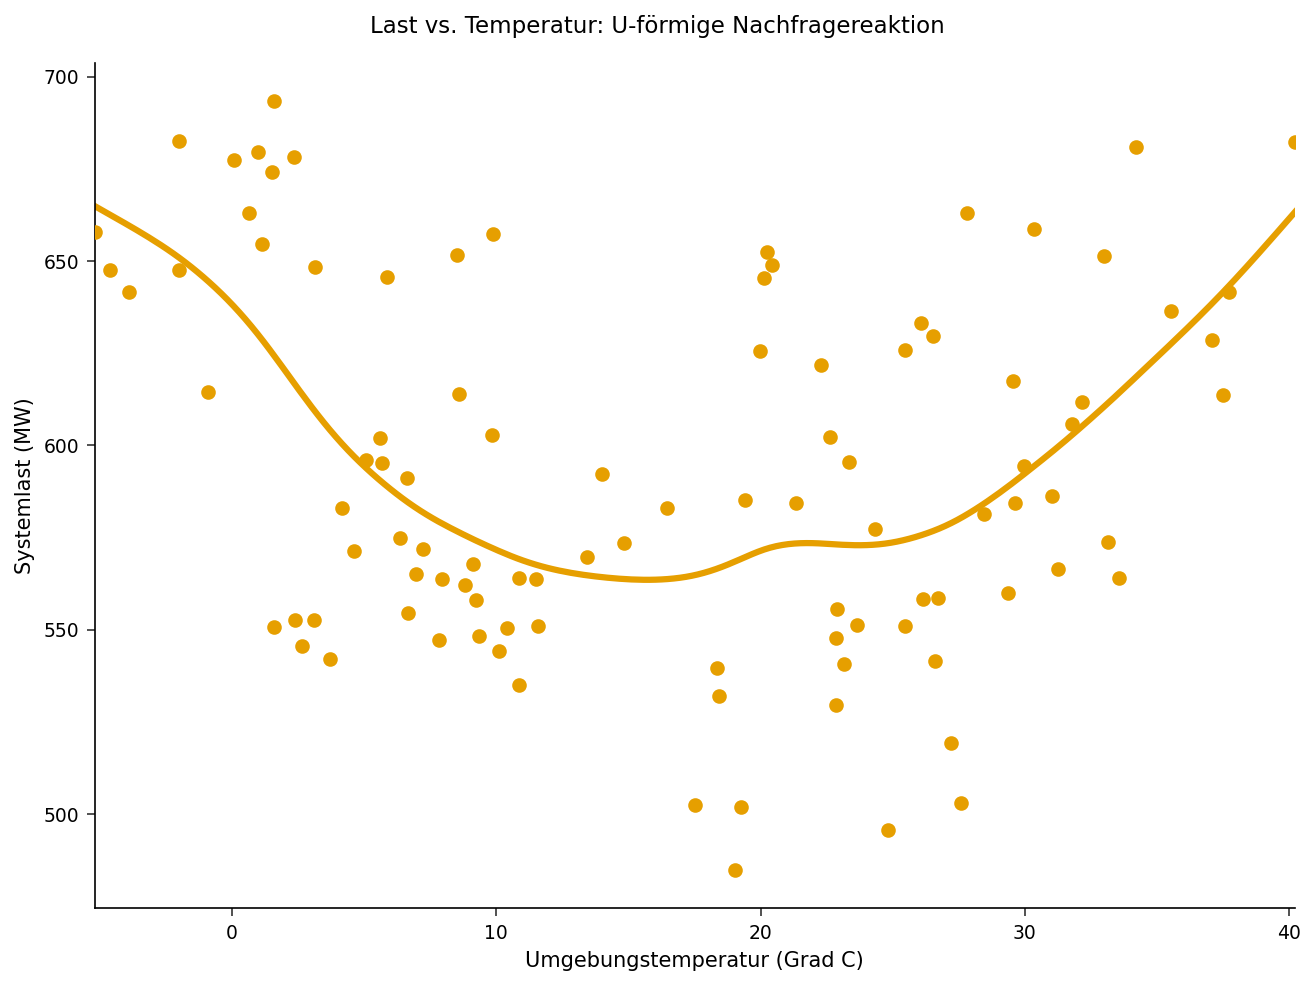

In [4]:
ODS GRAPHICS ON;

PROZEDUR SGPLOT DATEN=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS BEZEICHNUNG="Umgebungstemperatur (Grad C)";
   YAXIS BEZEICHNUNG="Systemlast (MW)";
   TITEL "Last vs. Temperatur: U-förmige Nachfragereaktion";
AUSFÜHREN;

ODS GRAPHICS OFF;

## Schritt 5 — Numerische Bestätigung der U-Form

Der Plot macht die U-Form sichtbar; eine gebänderte Zusammenfassung macht sie quantitativ. Wir bilden Temperaturbänder aus den Beobachtungen und berichten die mittlere Last je Band. Wenn die Bedarfsreaktion tatsächlich U-förmig ist, sollte die mittlere Last im Band **Kalt** hoch sein, über **Kühl / Angenehm / Warm** fallen und im Band **Heiß** wieder ansteigen — die numerische Signatur, die der Smooth `s(TEMP_C)` von GAMPL erfasst.

In [5]:
DATEN work.banded;
   FESTLEGEN work.gridload;
   LÄNGE tempband $13;
   WENN      temp_c <  5  DANN tempband = "1 Kalt";
   SONST WENN temp_c < 15  DANN tempband = "2 Kühl";
   SONST WENN temp_c < 22  DANN tempband = "3 Angenehm";
   SONST WENN temp_c < 30  DANN tempband = "4 Warm";
   SONST                      tempband = "5 Heiß";
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=work.banded n mean maxdec=1;
   KLASSE tempband;
   VAR load_mw;
   BEZEICHNUNG tempband="Temperaturband" load_mw="Systemlast (MW)";
   TITEL "Mittlere Last nach Temperaturband";
AUSFÜHREN;

                                           Mittlere Last nach Temperaturband                                            

                                                  The MEANS Procedure

                                      Analysis Variable : load_mw Systemlast (MW)

        Temperaturband          N Obs           Mean
        --------------------------------------------
        1 Kalt                     21          626.6
        2 Kühl                     28          579.1
        3 Angenehm                 12          573.8
        4 Warm                     25          573.5
        5 Heiß                     14          621.6
        --------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretation der Ergebnisse

**Die Smooths rekonstruieren die Physik.** Die Smoothing-Component-Tabelle von GAMPL weist dem Temperaturterm `s(TEMP_C)` einen effektiven DF von 5,53 (*p* < 0,0001) und dem Tagesverlaufsterm `s(HOUR)` einen EDF von 6,87 (*p* < 0,0001) zu — beide echt gekrümmt, genau die Struktur, die wir in die Daten eingebaut haben. Der Luftfeuchtigkeitsterm `s(HUMIDITY)` wird auf EDF 1,00 geschrumpft (*p* = 0,07): Die Penalisierung glättet ihn zu einem einzigen, nahezu linearen Freiheitsgrad, weil bei dieser Stichprobengröße die Daten nicht mehr hergeben. Die parametrische `daytype`-Schätzung beträgt −44,5 MW für Wochenenden und rekonstruiert damit die 40-MW-Wochentagsniveauverschiebung im generierenden Prozess.

**Effektive Freiheitsgrade erzählen die Geschichte der Gewelltheit.** Das Modell verbraucht insgesamt 15,4 effektive Freiheitsgrade und landet bei einem GCV-Wert von 239,6 (AIC 831,0, Skalenschätzung 202,7). Die Begrenzung durch `maxdf=` und die Fixierung von `df=3` in Schritt 3 verändert die Anpassung kaum (GCV 240,1, EDF 15,47): Die Penalisierung hatte die Temperatur- und Stunden-Smooths bereits von sich aus nahe 5,5 bzw. 7 EDF eingependelt, sodass die manuellen Obergrenzen hier nicht bindend sind — ein Zeichen, dass die automatische Auswahl bereits konservativ war.

**Der Plot und die Bandzusammenfassung stimmen überein.** Das Streudiagramm aus Schritt 4 mit seiner penalisierten Spline-Überlagerung zeigt, wie die Last vom kalten Extrem auf ein Minimum nahe 15–20 Grad C fällt und in die Hitze hinein wieder ansteigt. Die Bandmittelwerte aus Schritt 5 machen es numerisch: **Kalt 626,6 MW**, **Kühl 579,1**, **Angenehm 573,8**, **Warm 573,5**, **Heiß 621,6** — hoch an beiden Enden, am niedrigsten in der angenehmen Mitte. Genau dieses U würde ein einzelner linearer `temp_c`-Term wegmitteln.

**Warum GAMPL gegenüber linearer Regression hier vorzuziehen ist.** Ein einzelner linearer `temp_c`-Term würde die Heiz- und Kühlregime zu einer nahezu flachen Steigung verschmelzen und dabei beide Extreme stark falsch prognostizieren — genau die Stunden, in denen Netzbelastung und Preisspitzen auftreten. Die additive Spline-Formulierung bewahrt die Interpretierbarkeit einer Regression (jeder Treiber liefert einen additiven Effekt), während sie den Daten überlässt, die Form jedes Effekts zu bestimmen. Natürliche Erweiterungen für einen Versorger umfassen eine `dist=gamma`-Anpassung, falls die Last multiplikativ modelliert wird, einen bivariaten `spline(temp_c hour)`, um zu erfassen, wie sich die Tagesspitze mit der Saison verschiebt, sowie `by`-Verarbeitung, um separate Modelle je Umspannwerk anzupassen.